In [1]:
!pip install pandas scikit-learn

In [2]:
import pandas as pd

df = pd.read_csv('/content/olist_orders_dataset.csv')

# Missing values check
print("Missing Values:\n", df.isnull().sum())

# Duplicate check
print("Duplicates:", df.duplicated().sum())

# Data types
print(df.dtypes)

Missing Values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicates: 0
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['purchase_day'] = df['order_purchase_timestamp'].dt.day
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

In [5]:
df_numeric = df[['purchase_hour', 'purchase_day', 'purchase_month']].copy()

In [6]:
df_numeric.fillna(df_numeric.mean(), inplace=True)

In [7]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)

df['anomaly'] = model.fit_predict(df_numeric)

print(df['anomaly'].value_counts())

anomaly
 1    94479
-1     4962
Name: count, dtype: int64


In [8]:
df['is_weekend'] = df['order_purchase_timestamp'].dt.dayofweek >= 5

df_numeric = df[['purchase_hour', 'purchase_day', 'purchase_month', 'is_weekend']]

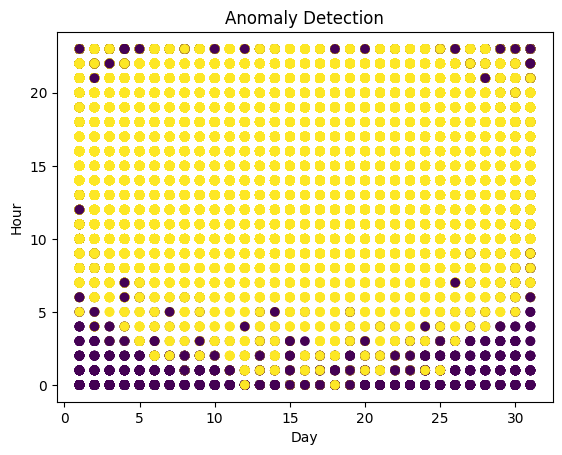

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['purchase_day'], df['purchase_hour'], c=df['anomaly'])
plt.title("Anomaly Detection")
plt.xlabel("Day")
plt.ylabel("Hour")
plt.show()